In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
salary_data=pd.read_csv("Salary_dataset.csv")

In [3]:
salary_data

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [4]:
salary_data.info

<bound method DataFrame.info of     Unnamed: 0  YearsExperience    Salary
0            0              1.2   39344.0
1            1              1.4   46206.0
2            2              1.6   37732.0
3            3              2.1   43526.0
4            4              2.3   39892.0
5            5              3.0   56643.0
6            6              3.1   60151.0
7            7              3.3   54446.0
8            8              3.3   64446.0
9            9              3.8   57190.0
10          10              4.0   63219.0
11          11              4.1   55795.0
12          12              4.1   56958.0
13          13              4.2   57082.0
14          14              4.6   61112.0
15          15              5.0   67939.0
16          16              5.2   66030.0
17          17              5.4   83089.0
18          18              6.0   81364.0
19          19              6.1   93941.0
20          20              6.9   91739.0
21          21              7.2   98274.0
22

In [5]:
salary_data.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [6]:
salary_data.head(10)

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [7]:
salary_data.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [8]:
salary_data.columns

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

In [9]:
#our x will be years of experience and y will be the salaries 

X=salary_data.iloc[:,1:2].values
X

array([[ 1.2],
       [ 1.4],
       [ 1.6],
       [ 2.1],
       [ 2.3],
       [ 3. ],
       [ 3.1],
       [ 3.3],
       [ 3.3],
       [ 3.8],
       [ 4. ],
       [ 4.1],
       [ 4.1],
       [ 4.2],
       [ 4.6],
       [ 5. ],
       [ 5.2],
       [ 5.4],
       [ 6. ],
       [ 6.1],
       [ 6.9],
       [ 7.2],
       [ 8. ],
       [ 8.3],
       [ 8.8],
       [ 9.1],
       [ 9.6],
       [ 9.7],
       [10.4],
       [10.6]])

In [10]:
y=salary_data.iloc[:,2:].values

In [11]:
y

array([[ 39344.],
       [ 46206.],
       [ 37732.],
       [ 43526.],
       [ 39892.],
       [ 56643.],
       [ 60151.],
       [ 54446.],
       [ 64446.],
       [ 57190.],
       [ 63219.],
       [ 55795.],
       [ 56958.],
       [ 57082.],
       [ 61112.],
       [ 67939.],
       [ 66030.],
       [ 83089.],
       [ 81364.],
       [ 93941.],
       [ 91739.],
       [ 98274.],
       [101303.],
       [113813.],
       [109432.],
       [105583.],
       [116970.],
       [112636.],
       [122392.],
       [121873.]])

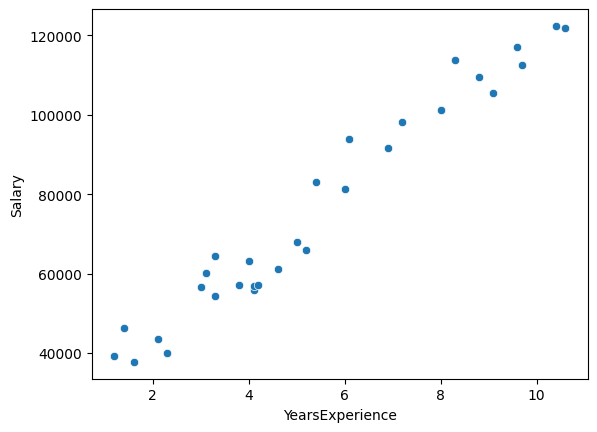

In [12]:
sns.scatterplot(x='YearsExperience',y='Salary',data=salary_data)
plt.show()

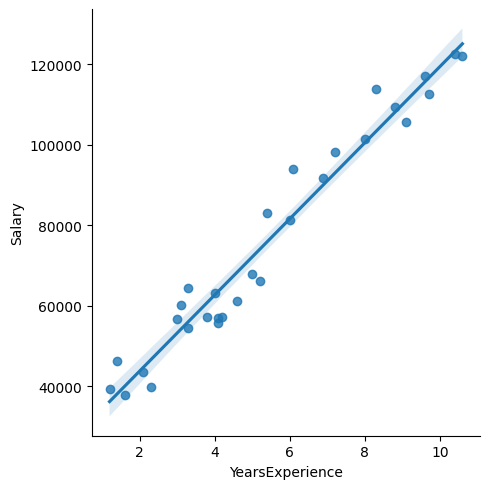

In [13]:
sns.lmplot(x='YearsExperience',y='Salary',data=salary_data)
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train,X_test,y_train,y_test= train_test_split(X,y,random_state=1)

In [16]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(22, 1)
(22, 1)
(8, 1)
(8, 1)


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [18]:
print("intercept =",lr.intercept_)
print("coefficent =",lr.coef_)

intercept = [24967.14887377]
coefficent = [[9261.56845302]]


In [19]:
y_pred=lr.predict(X_test)
y_pred

array([[ 74979.61852009],
       [ 91650.44173553],
       [ 62013.42268586],
       [ 81462.7164372 ],
       [ 67570.36375767],
       [ 88871.97119962],
       [113878.20602278],
       [ 44416.44262512]])

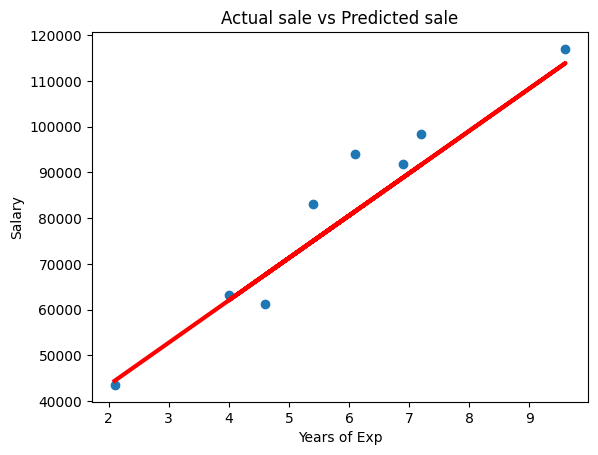

In [20]:
import matplotlib.pyplot as plt
plt.scatter(x=X_test,y=y_test)
plt.plot(X_test,y_pred,color="red",linewidth=3)
plt.title("Actual sale vs Predicted sale")
plt.xlabel("Years of Exp")
plt.ylabel("Salary")
plt.show()

In [21]:
print("Mean absolute error (MAE):", metrics.mean_absolute_error(y_test,y_pred))
print("Mean square error (MSE):", metrics.mean_squared_error(y_test,y_pred))
print("R-squared value of predictions:",metrics.r2_score(y_test,y_pred))

Mean absolute error (MAE): 5215.553722712967
Mean square error (MSE): 40884620.50478403
R-squared value of predictions: 0.9180980074804028


In [22]:
z= pd.DataFrame(y_test[:10])

In [23]:
z

,0
0,83089.0
1,98274.0
2,63219.0
3,93941.0
4,61112.0
5,91739.0
6,116970.0
7,43526.0


In [26]:
df_check = pd.DataFrame({'Actual': z.iloc[:, 0], 'Predicted': y_pred[:10].ravel()})
df_check

,Actual,Predicted
0,83089.0,74979.618520
1,98274.0,91650.441736
2,63219.0,62013.422686
3,93941.0,81462.716437
4,61112.0,67570.363758
5,91739.0,88871.971200
6,116970.0,113878.206023
7,43526.0,44416.442625


Text(14.934305555555556, 0.5, 'count')

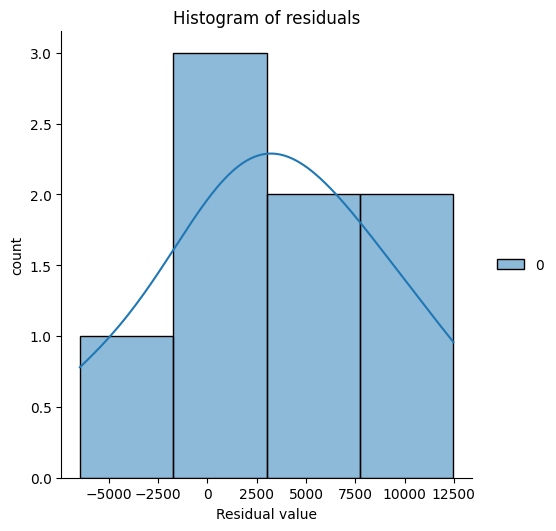

In [27]:
import seaborn as sns
 ## first compute vector of residuals. 
resids = np.subtract(y_test, y_pred)

## now make the residual plots
sns.displot(resids, kde = True)
plt.title('Histogram of residuals')
plt.xlabel('Residual value')
plt.ylabel('count')

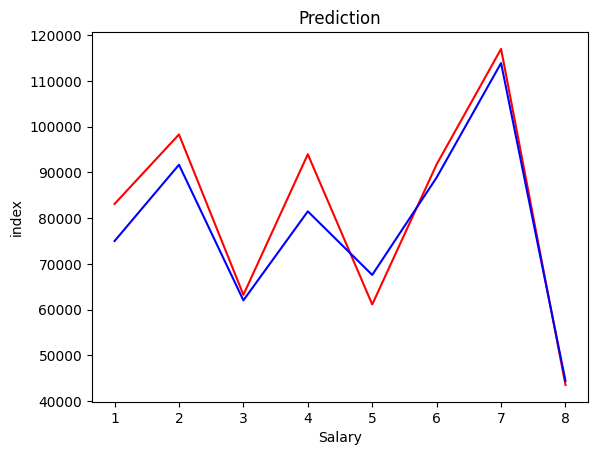

In [28]:
# Plotting the actual and predicted values

c = [i for i in range (1,len(y_test)+1,1)]
plt.plot(c,y_test,color='r',linestyle='-')
plt.plot(c,y_pred,color='b',linestyle='-')
plt.xlabel('Salary')
plt.ylabel('index')
plt.title('Prediction')
plt.show()

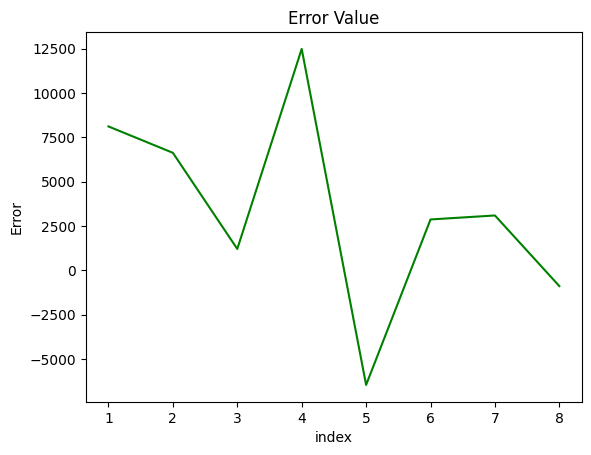

In [29]:
# plotting the error
c = [i for i in range(1,len(y_test)+1,1)]
plt.plot(c,y_test-y_pred,color='green',linestyle='-')
plt.xlabel('index')
plt.ylabel('Error')
plt.title('Error Value')
plt.show()

In [30]:
# Importing metrics for the evaluation of the model
from sklearn.metrics import r2_score,mean_squared_error

In [31]:
# calculate Mean square error
mse = mean_squared_error(y_test,y_pred)

In [32]:
# Calculate R square vale
rsq = r2_score(y_test,y_pred)

In [33]:
print('mean squared error :',mse)
print('r square :',rsq)

mean squared error : 40884620.50478403
r square : 0.9180980074804028


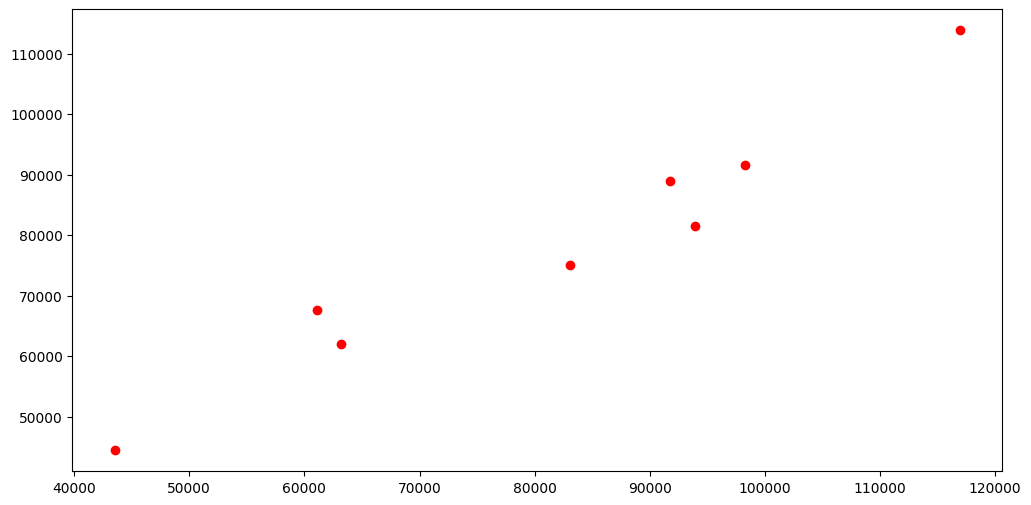

In [34]:
# Just plot actual and predicted values for more insights
plt.figure(figsize=(12,6))
plt.scatter(y_test,y_pred,color='r',linestyle='-')
plt.show()

In [35]:
# Intecept and coeff of the line
print('Intercept of the model:',lr.intercept_)
print('Coefficient of the line:',lr.coef_)

Intercept of the model: [24967.14887377]
Coefficient of the line: [[9261.56845302]]


## 🎯 Conclusion & Next Steps

## The linear regression model for salary prediction is :  y = 24967.1 + 9261.5 x

### ✅ Key Takeaways
- We successfully built a **Linear Regression model** to predict salaries based on years of experience.
- The model's **performance metrics** (MSE, R² Score) help assess its accuracy.
- A new salary prediction can be made by simply inputting years of experience.

### 🚀 Possible Improvements
🔹 **Add More Features**: Consider factors like **education level, job industry, location** for better predictions.  
🔹 **Try Other Models**: Experiment with **Polynomial Regression, Decision Trees, or Random Forest**.  
🔹 **Hyperparameter Tuning**: Use **GridSearchCV** to optimize model performance.  

### 🔥 What's Next?
Would you like to deploy this model as a simple web app or integrate it into a data dashboard? Let’s take it to the next level! 🚀
